# CNN-Based Image Analysis Using Pretrained Models
### Industry Assignment

This notebook demonstrates how to analyze images using a **pretrained Convolutional Neural Network (CNN)** instead of training a model from scratch.

Objectives:
- Understand the structure of a CNN
- Use a pretrained CNN model
- Visualize feature maps
- Interpret model predictions


## Task 1: Load a Pretrained CNN Model

We will use **ResNet50**, a widely used pretrained CNN trained on the ImageNet dataset.

In [1]:
import torch
import torchvision.models as models

# Load pretrained ResNet50 model
model = models.resnet50(pretrained=True)

# Set model to evaluation mode
model.eval()

# Display model architecture
print(model)

c:\Users\Ved Dhanokar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Ved Dhanokar\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Ved Dhanokar/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:14<00:00, 7.20MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Task 2: Image Preprocessing

Steps involved:
1. Load an image
2. Resize image to 224x224
3. Convert to tensor
4. Normalize according to ImageNet statistics

In [3]:
from PIL import Image
from torchvision import transforms

# Image path (replace with your image)
image_path = 'image.jpeg'

image = Image.open(image_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

input_tensor = transform(image).unsqueeze(0)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


## Task 3: Feature Extraction

We will extract **feature maps from early convolution layers**.

In [4]:
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)

# Register hook to first convolution layer
hook = model.conv1.register_forward_hook(hook_fn)

# Forward pass
with torch.no_grad():
    model(input_tensor)

hook.remove()

feature_maps = feature_maps[0]
print(feature_maps.shape)

torch.Size([1, 64, 112, 112])


## Task 4: Feature Map Visualization

Visualizing **6 feature maps** from the first convolution layer.

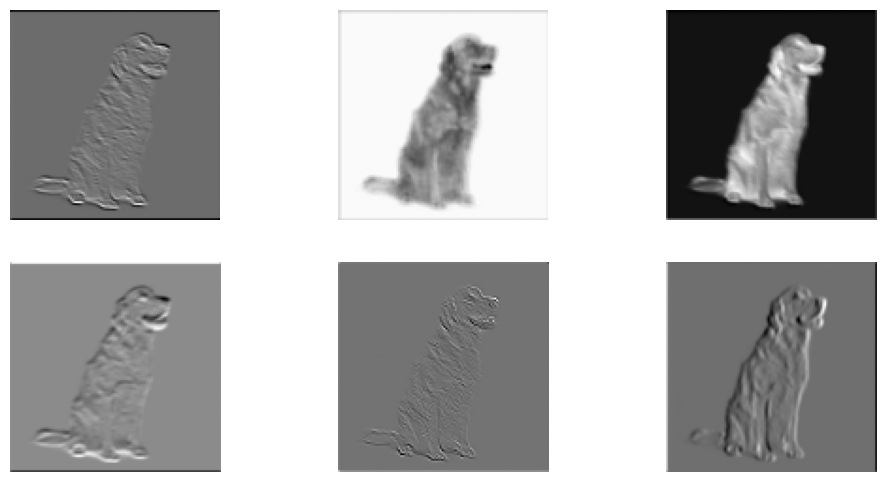

In [5]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12,6))

for i in range(6):
    ax = fig.add_subplot(2,3,i+1)
    ax.imshow(feature_maps[0,i].cpu(), cmap='gray')
    ax.axis('off')

plt.show()

### Observation

Early CNN layers usually capture:
- Edges
- Color gradients
- Simple textures
These low-level features are combined by deeper layers to form complex object representations.

## Task 5: Prediction Using Pretrained CNN

In [6]:
import torch.nn.functional as F

with torch.no_grad():
    outputs = model(input_tensor)

probabilities = F.softmax(outputs[0], dim=0)

top3_prob, top3_catid = torch.topk(probabilities, 3)

print('Top 3 Predictions:')
for i in range(3):
    print(top3_catid[i].item(), top3_prob[i].item())

Top 3 Predictions:
207 0.8661096692085266
222 0.08883123844861984
208 0.013742825016379356


## Analysis Questions

### 1. What patterns do early CNN layers detect?
Early CNN layers detect simple features such as edges, corners, lines, and color gradients.

### 2. How do deeper layers differ from earlier layers?
Deeper layers detect high-level semantic features such as shapes, textures, and entire objects.

### 3. Why are pretrained models widely used in industry?
- Reduce training time
- Require less data
- Provide strong baseline performance

### 4. Advantages of Transfer Learning
- Faster model development
- Lower computational cost
- Improved accuracy on small datasets
